In [1]:
!pip install ultralytics
!pip install matplotlib opencv-python
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.5 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

# Load your trained YOLOv8 model
model = YOLO("/kaggle/input/datasets/pmtasrifulislam/yolo-v8l-best-model/archive/dataset/best.pt")
model.fuse()  # optional: fuse conv+BN for faster inference

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model summary (fused): 113 layers, 43,611,234 parameters, 0 gradients, 164.8 GFLOPs


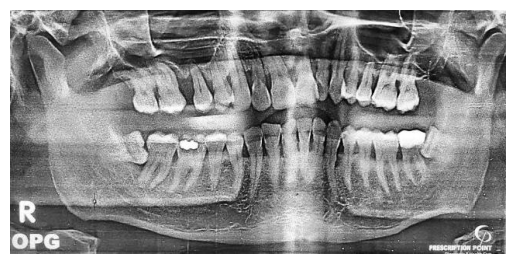

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "/kaggle/input/datasets/pmtasrifulislam/yolo-v8l-best-model/archive/dataset/train/images/108_jpg.rf.0827b88973f3beb8f69f0205790dd76b.jpg"
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
H, W, _ = img.shape

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

In [4]:
def occlusion_heatmap(model, image, patch_size=32, stride=16):
    H, W, _ = image.shape
    heatmap = np.zeros((H, W))
    
    # Original prediction confidence (sum of detected object confidences)
    results = model.predict(image, imgsz=640)
    base_conf = sum([box.conf.item() for box in results[0].boxes])

    # Slide patch over image
    for y in range(0, H, stride):
        for x in range(0, W, stride):
            img_copy = image.copy()
            
            # Apply black patch
            y1, y2 = y, min(y + patch_size, H)
            x1, x2 = x, min(x + patch_size, W)
            img_copy[y1:y2, x1:x2] = 0  # black patch
            
            # Predict again
            results_patch = model.predict(img_copy, imgsz=640)
            patch_conf = sum([box.conf.item() for box in results_patch[0].boxes])
            
            # Importance: drop in confidence
            heatmap[y1:y2, x1:x2] += base_conf - patch_conf

    # Normalize heatmap
    heatmap = heatmap / np.max(heatmap)
    return heatmap


0: 320x640 1 Healthy Teeth, 2 Impacted Teeths, 2 Fractured Teeths, 91.9ms
Speed: 4.2ms preprocess, 91.9ms inference, 40.3ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 Healthy Teeth, 2 Impacted Teeths, 2 Fractured Teeths, 37.4ms
Speed: 1.7ms preprocess, 37.4ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 Healthy Teeth, 2 Impacted Teeths, 2 Fractured Teeths, 37.5ms
Speed: 1.5ms preprocess, 37.5ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 Healthy Teeth, 2 Impacted Teeths, 2 Fractured Teeths, 37.5ms
Speed: 1.0ms preprocess, 37.5ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 Healthy Teeth, 2 Impacted Teeths, 2 Fractured Teeths, 37.6ms
Speed: 1.0ms preprocess, 37.6ms inference, 2.1ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 Healthy Teeth, 2 Impacted Teeths, 2 Fractured Teeths, 34.8ms
Speed: 1.3ms preprocess, 34.8ms inference, 1.3ms postprocess per

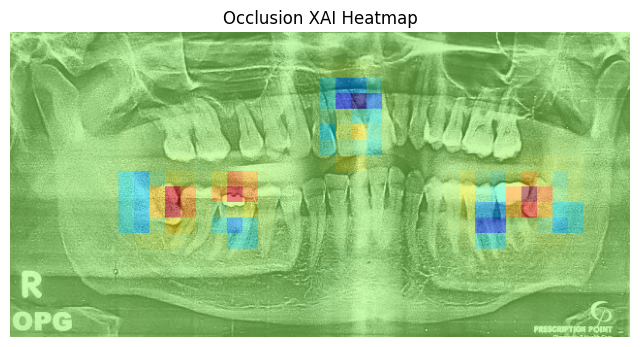

In [5]:
heatmap = occlusion_heatmap(model, img_rgb, patch_size=32, stride=16)

plt.figure(figsize=(8,8))
plt.imshow(img_rgb)
plt.imshow(heatmap, cmap='jet', alpha=0.5)  # overlay heatmap
plt.axis('off')
plt.title("Occlusion XAI Heatmap")
plt.show()


0: 320x640 1 Healthy Teeth, 2 Impacted Teeths, 2 Fractured Teeths, 16.6ms
Speed: 1.2ms preprocess, 16.6ms inference, 1.4ms postprocess per image at shape (1, 3, 320, 640)


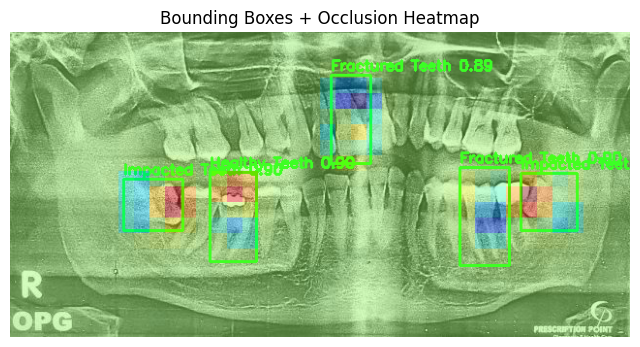

In [6]:
results = model.predict(img_rgb, imgsz=640)

for box in results[0].boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    cls = int(box.cls[0])
    conf = box.conf[0].item()
    label = f"{model.names[cls]} {conf:.2f}"
    
    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0,255,0), 2)
    cv2.putText(img_rgb, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

plt.figure(figsize=(8,8))
plt.imshow(img_rgb)
plt.imshow(heatmap, cmap='jet', alpha=0.4)
plt.axis('off')
plt.title("Bounding Boxes + Occlusion Heatmap")
plt.show()